<h1><center><b>💻 Assignment 1:</b> </br>👋 Introduction to Graph!</center></h1>

# ✨ **Excercise 1:** **Local Area Network (LAN)**

> 💭 Imagine this graph represents a small **Local Area Network (LAN)** where nodes are routers and edges are physical fiber connections.

Given Edges: `[(1, 2), (1, 3), (2, 3), (2, 4), (4, 5), (5, 6), (5, 7), (6, 7), (8, 9)]`

1. Manual Mapping: Draw the graph. Label all nodes and edges clearly.
2. Check if node 8 wants to send data to node 1, is it possible? 
3. Identify the Hub (the node with the highest degree)
4. Identify any edge that, if removed, would increase the number of connected components.
5. Calculate the Graph Density using the formula: $D = \frac{2|E|}{|V|(|V|-1)}$
6. Create a simple histogram of the degrees.

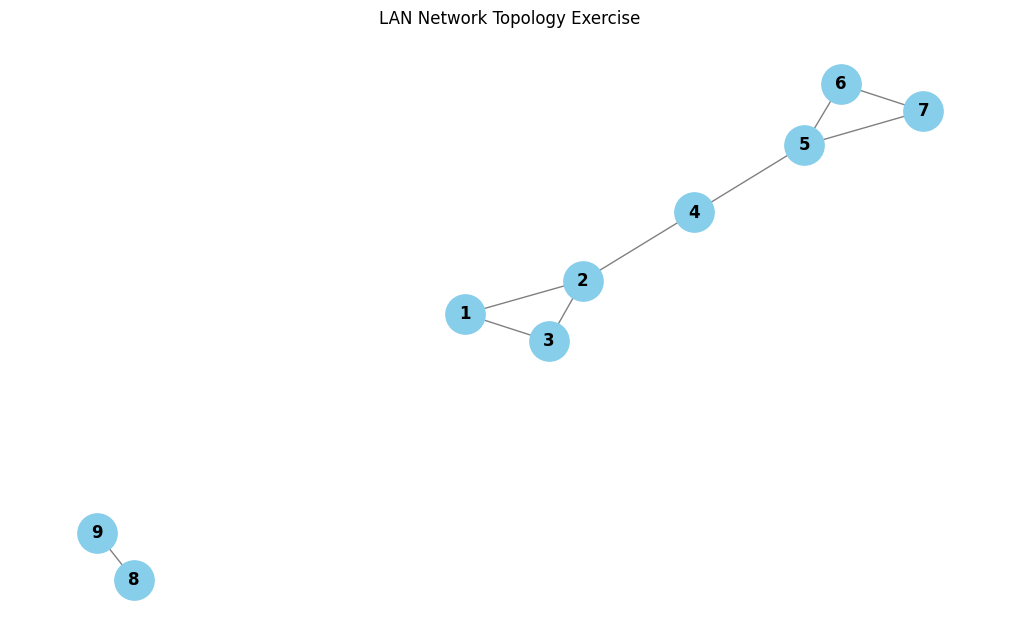

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Initialize the Graph

G = nx.Graph()
edges = [(1, 2), (1, 3), (2, 3), (2, 4), (4, 5), (5, 6), (5, 7), (6, 7), (8, 9)
         ]
G.add_edges_from(edges)

# 2. Visualization
fig = plt.figure(figsize=(10,6))
pos = nx.spring_layout(G, seed=42) # This ensure the consistant layout
nx.draw(G, 
        pos, 
        with_labels=True, 
        node_color='skyblue', 
        node_size=800, 
        font_weight='bold', 
        edge_color='gray')

plt.title("LAN Network Topology Exercise")
plt.show()

In [3]:
#2. Connected Components and Path Existence
components = list(nx.connected_components(G))
print(f"Connected Components: {components}")
print(f"Is Node 8 connected to Node 1? {nx.has_path(G, 8, 1) if 8 in G and 1 in G else False}")

Connected Components: [{1, 2, 3, 4, 5, 6, 7}, {8, 9}]
Is Node 8 connected to Node 1? False


In [4]:
#3. Hubs and Degree
node_degrees = dict(G.degree())
max_degree = max(node_degrees.values())
hubs = [node for node, degree in node_degrees.items() if degree == max_degree]

print(f"The maximum Degree is: {max_degree}")
print(f"Network Hub(s): {hubs}")

The maximum Degree is: 3
Network Hub(s): [2, 5]


In [5]:
#4. Bridges (Critical Connections - Edge whose removal increases the number of connected components)
bridges = list(nx.bridges(G))
print(f"Bridge: {bridges}")

Bridge: [(2, 4), (4, 5), (8, 9)]


In [7]:
#5. Graph Density
nodes_count = G.number_of_nodes()
edges_count = G.number_of_edges()
manual_density = (2 * edges_count) / (nodes_count * (nodes_count - 1))

print(f"Total Nodes: {nodes_count}")
print(f"Total Edges: {edges_count}")
print(f"Graph Density: {manual_density:.2f}")

# Optional: Verify with NetworkX built-in function
# nx_density = nx.density(G)
# if round(manual_density, 4) == round(nx_density, 4):
#     print("\n✅ The results match!")
# else:
#     print("\n❌ There is a discrepancy.")

Total Nodes: 9
Total Edges: 9
Graph Density: 0.25



Node degrees: {1: 2, 2: 3, 3: 2, 4: 2, 5: 3, 6: 2, 7: 2, 8: 1, 9: 1}


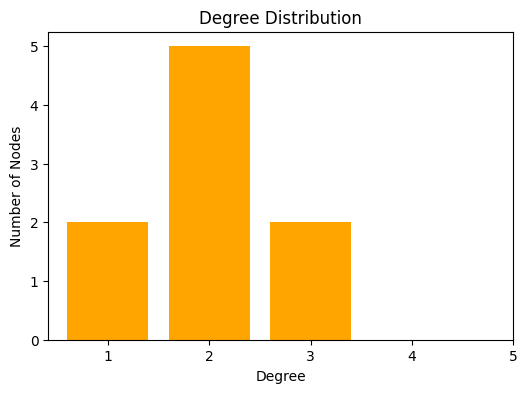

In [8]:
#6. Plot the Degree Distribution
# Degree distribution

degrees = [G.degree(n) for n in G.nodes()]
print(f"\nNode degrees: {dict(G.degree())}")

# Plotting

plt.figure(figsize=(6, 4))
plt.hist(degrees, 
         bins=range(1, 6), 
         align='left', 
         rwidth=0.8, 
         color='orange')

plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Number of Nodes")

plt.xticks(range(1, 6))
plt.show()

# ✨ **Excercise 2:** **Social Network Analysis**

> You are given a dataset representing a social network where individuals are connected by different types of relationships: friend, coworker, family, and neighbour.

👉 Tasks:
1. Use NetworkX to read the file `practice.txt` and then visualize the graph.
2. Print the total number of unique individuals (nodes) and unique connection pairs (edges).
3. Display the full list of names in the network.
4. Identify and print all neighbors of David.
    > ❗Conditional Query: List only those neighbors of David who are specifically labeled as his `friend`.
5. Calculate the degree of David.
6. Find the Average Degree of the entire network.
7. Find and print the relationship type(s) between David and Amy.
8. Identify all "Influencers": nodes with a degree greater than 3.
9. Determine if the social network is fully connected or if there are isolated groups.


In [ ]:
# Again, import the library
import networkx as nx
import matplotlib.pyplot as plt

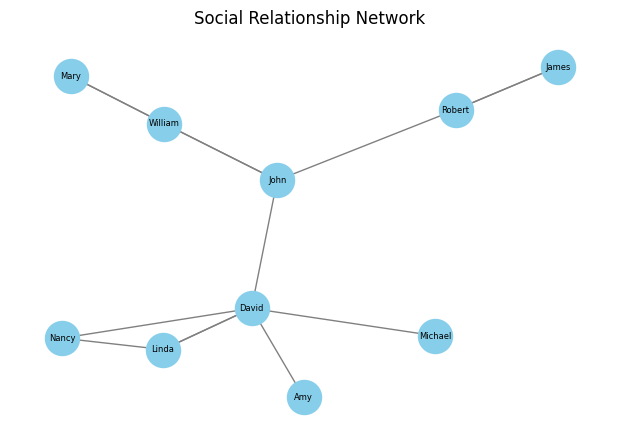

In [9]:
#1. Initialize the Graph
# Load the data and build graph
graph_type = nx.MultiGraph()
G = nx.read_edgelist("./data/practice1.txt",
                     create_using=graph_type,
                     data=[('relation', str)])
# nx.draw_networkx(G, 
#                  with_labels=True,
#                  font_size=6,
#                  node_size=600,
#                  node_color='skyblue',
#                  edge_color='gray',
#                  )

#2. Visualization
plt.figure(figsize=(6, 4))
pos = nx.spring_layout(G, seed=42)
nx.draw(G,
        pos,
        with_labels=True,
        node_color='skyblue',
        # node_color='lightgreen',
        node_size=600,
        font_size=6,
        edge_color='gray')
plt.title("Social Relationship Network")
plt.show()



In [ ]:
#3. Print full list of names

# Print the summary
print(f"Total Nodes: {G.number_of_nodes()}")
print(f"Total Edges: {G.number_of_edges()}")
print(f"All Nodes: {list(G.nodes())}")
print(f"All Edges: {list(G.edges())}")

Total Nodes: 10
Total Edges: 14
All Nodes: ['James', 'Robert', 'John', 'William', 'Mary', 'David', 'Michael', 'Linda', 'Nancy', 'Amy']
All Edges: [('James', 'Robert'), ('James', 'Robert'), ('Robert', 'John'), ('John', 'William'), ('John', 'William'), ('John', 'David'), ('William', 'Mary'), ('William', 'Mary'), ('David', 'Michael'), ('David', 'Linda'), ('David', 'Linda'), ('David', 'Nancy'), ('David', 'Amy'), ('Linda', 'Nancy')]


In [ ]:
#4. Identify and print all neighbors of David and filter those with 'friend' relationship
# Neighbor Query
david_neighbors = list(G.neighbors("David"))
print(f"\nDavid's Neighbors: {david_neighbors}")

david_friends = [n for n in david_neighbors if 'friend' in G["David"][n][0]['relation']]
print(f"David's Friends: {david_friends}")


David's Neighbors: ['John', 'Michael', 'Linda', 'Nancy', 'Amy']
David's Friends: ['John', 'Nancy']


In [ ]:
#5. Degree of David

print(f"\nDegree of David: {G.degree('David')}")

#6. Average Network Degree
avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
print(f"Average Network Degree: {avg_degree:.2f}")


Degree of David: 6
Average Network Degree: 2.80


In [13]:
#7. Relationship between David and Amy
relation = G['David']['Amy'][0]['relation']
print(f"Relationship between David and Amy is {relation}")

Relationship between David and Amy is coworker


In [14]:
#8. Influencers (nodes with degree > 3)
influencer = [node for node, deg in G.degree if deg > 3]
print(f"Influencers list (nodes with degree > 3): {influencer}")

Influencers list (nodes with degree > 3): ['John', 'William', 'David']


In [15]:
#9. Is the graph connected?
print(f"Is the graph connected? {nx.is_connected(G)}")

Is the graph connected? True


<h3><center><b>💻🎉 CONGRATULATIONS! 🎉 </b> </center></h1>
<h4><center>You have finished your exercise! 🌟 Keep up the good work!</center></h2>